In [1]:
import matplotlib.pyplot as plt
import numpy as np


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

In [2]:
import os

os.makedirs("figures", exist_ok=True)

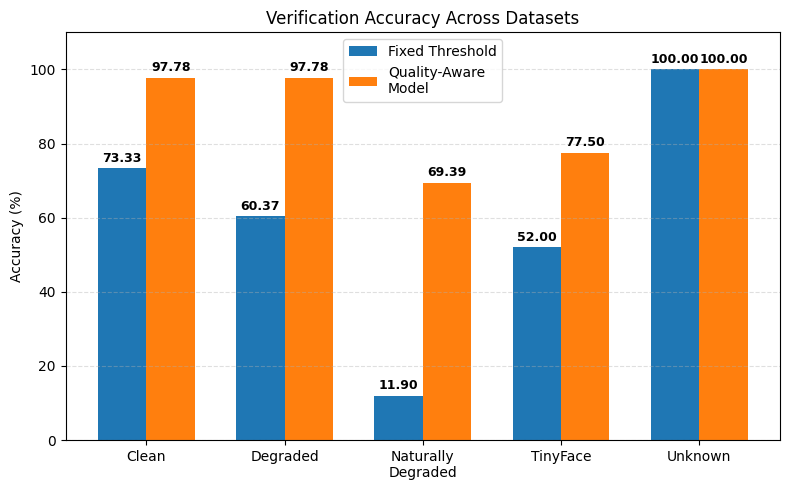

In [3]:
# accuracy comparison

datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
    "Unknown",
]

threshold_acc = [
    73.33,
    60.37,
    11.90,
    52.00,
    100.00,
]

mlp_acc = [
    97.78,
    97.78,
    69.39,
    77.50,
    100.00,
]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width / 2, threshold_acc, width, label="Fixed Threshold")

bars2 = plt.bar(x + width / 2, mlp_acc, width, label="Quality-Aware\nModel")

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, datasets)
plt.ylabel("Accuracy (%)")
plt.title("Verification Accuracy Across Datasets")
plt.legend()

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/accuracy_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

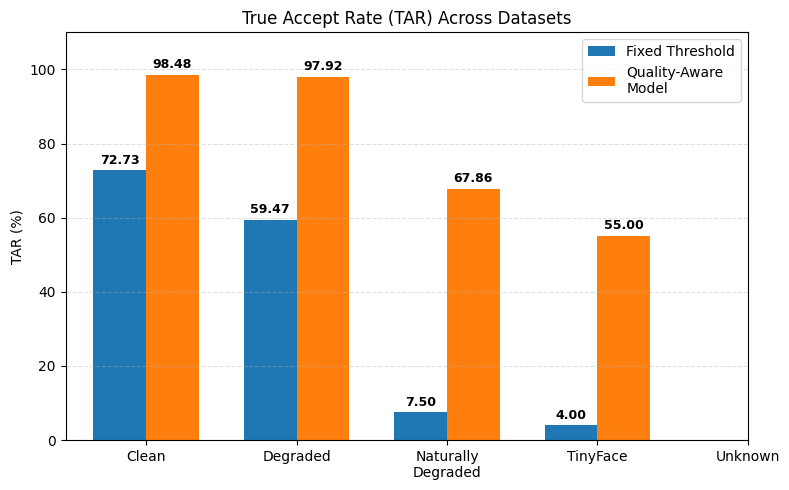

In [4]:
# TAR comparison
datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
    "Unknown",
]

threshold_tar = [
    72.73,
    59.47,
    7.50,
    4.00,
    np.nan,
]

mlp_tar = [
    98.48,
    97.92,
    67.86,
    55.00,
    np.nan,
]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width / 2, threshold_tar, width, label="Fixed Threshold")

bars2 = plt.bar(x + width / 2, mlp_tar, width, label="Quality-Aware\nModel")

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, datasets)
plt.ylabel("TAR (%)")
plt.title("True Accept Rate (TAR) Across Datasets")
plt.legend()

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/tar_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

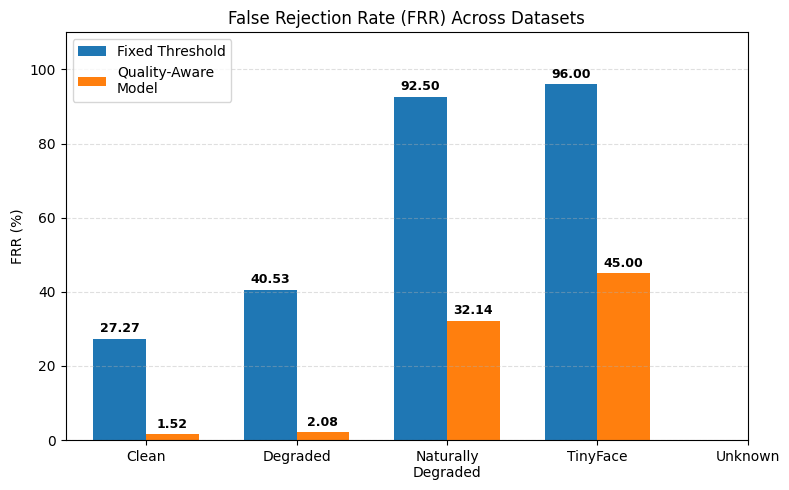

In [5]:
# FRR comparison
datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
    "Unknown",
]

threshold_frr = [
    27.27,
    40.53,
    92.50,
    96.00,
    np.nan,
]

mlp_frr = [
    1.52,
    2.08,
    32.14,
    45.00,
    np.nan,
]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width / 2, threshold_frr, width, label="Fixed Threshold")

bars2 = plt.bar(x + width / 2, mlp_frr, width, label="Quality-Aware\nModel")

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, datasets)
plt.ylabel("FRR (%)")
plt.title("False Rejection Rate (FRR) Across Datasets")
plt.legend()

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/frr_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

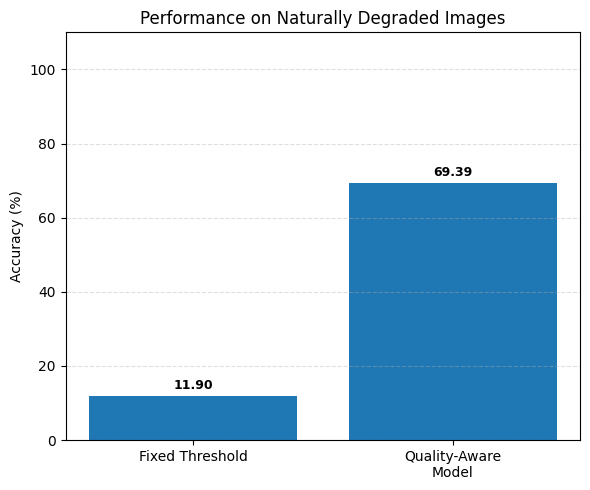

In [6]:
# naturally degraded dataset figure
methods = ["Fixed Threshold", "Quality-Aware\nModel"]

acc = [11.90, 69.39]

plt.figure(figsize=(6, 5))

bars = plt.bar(methods, acc)

add_labels(bars)

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.ylabel("Accuracy (%)")
plt.title("Performance on Naturally Degraded Images")


plt.tight_layout()
plt.savefig("figures/natural_dataset_accuracy.png", dpi=600, bbox_inches="tight")

plt.show()

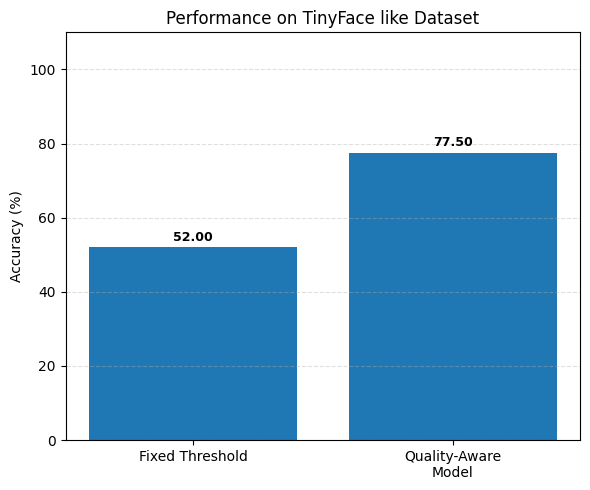

In [7]:
# tinyface like dataset
methods = ["Fixed Threshold", "Quality-Aware\nModel"]

acc = [52.00, 77.50]

plt.figure(figsize=(6, 5))

bars = plt.bar(methods, acc)

add_labels(bars)

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.ylabel("Accuracy (%)")
plt.title("Performance on TinyFace like Dataset")


plt.tight_layout()
plt.savefig(
    "figures/tinyface_dataset_accuracy.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

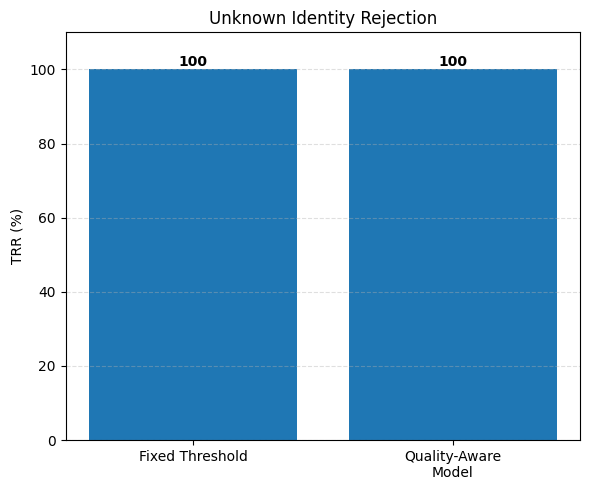

In [8]:
# unknown identity rejection
methods = ["Fixed Threshold", "Quality-Aware\nModel"]

trr = [100, 100]

plt.figure(figsize=(6, 5))

bars = plt.bar(methods, trr)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.ylabel("TRR (%)")
plt.title("Unknown Identity Rejection")

plt.ylim(0, 110)

plt.tight_layout()
plt.savefig("figures/unknown_identity_rejection.png", dpi=600, bbox_inches="tight")

plt.show()

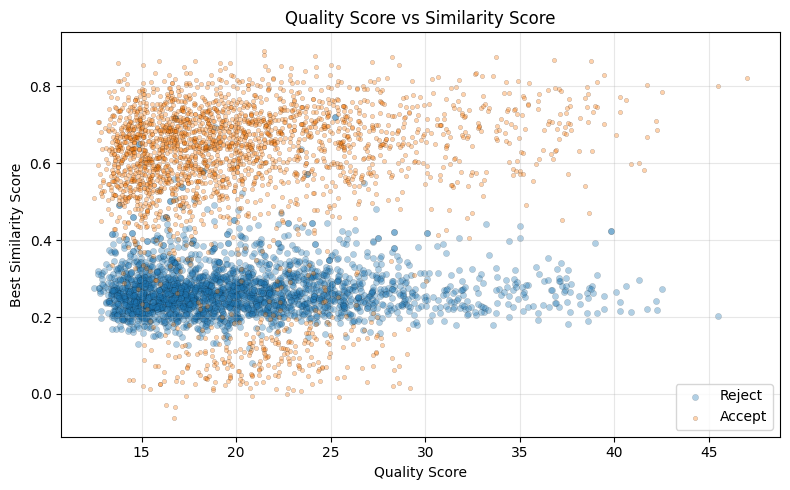

In [9]:
# Feature importnace figure
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/train_mlp_extended_final_plus_tinyface.csv"
)

accept = df[df["label"] == 1]
reject = df[df["label"] == 0]

plt.figure(figsize=(8, 5))

plt.scatter(
    reject["quality_score"],
    reject["best_similarity"],
    alpha=0.35,
    s=20,
    edgecolors="black",
    linewidths=0.2,
    label="Reject",
)

plt.scatter(
    accept["quality_score"],
    accept["best_similarity"],
    alpha=0.35,
    s=10,
    edgecolors="black",
    linewidths=0.25,
    label="Accept",
)

plt.xlabel("Quality Score")
plt.ylabel("Best Similarity Score")
plt.title("Quality Score vs Similarity Score")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/quality_similarity_scatter.png", dpi=600, bbox_inches="tight")

plt.show()

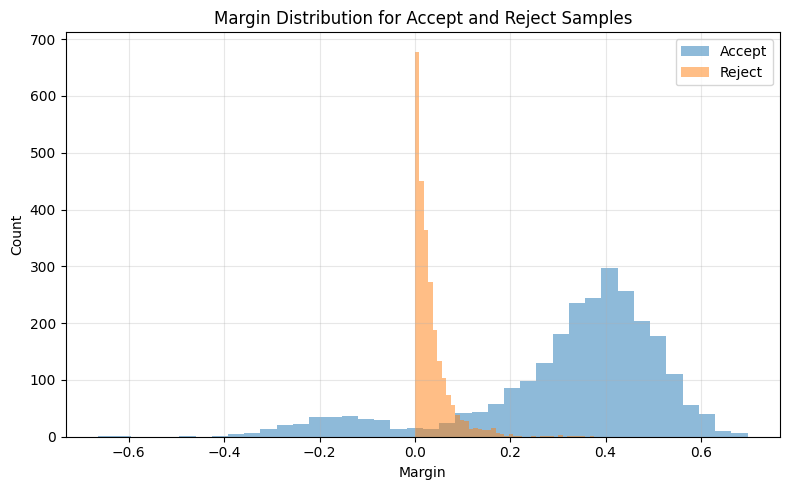

In [10]:
# margin distribution plot
plt.figure(figsize=(8, 5))

plt.hist(accept["margin"], bins=40, alpha=0.5, label="Accept")

plt.hist(reject["margin"], bins=40, alpha=0.5, label="Reject")

plt.xlabel("Margin")
plt.ylabel("Count")
plt.title("Margin Distribution for Accept and Reject Samples")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/margin_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

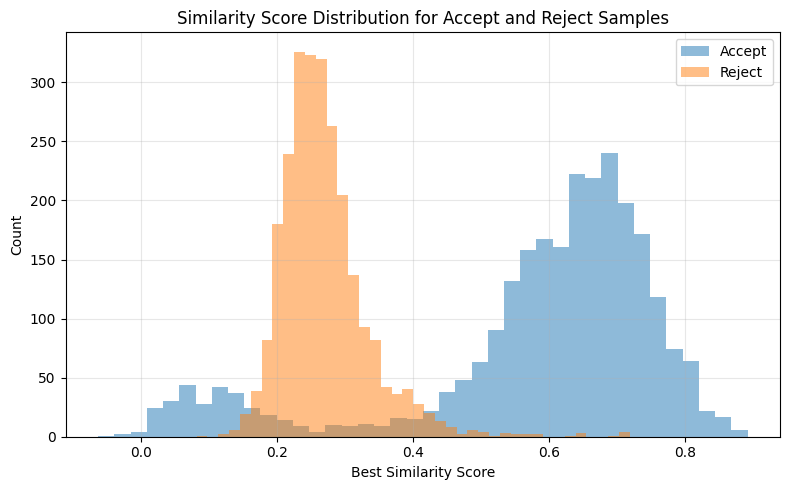

In [11]:
# similarity distribution
plt.figure(figsize=(8, 5))

plt.hist(accept["best_similarity"], bins=40, alpha=0.5, label="Accept")

plt.hist(reject["best_similarity"], bins=40, alpha=0.5, label="Reject")

plt.xlabel("Best Similarity Score")
plt.ylabel("Count")
plt.title("Similarity Score Distribution for Accept and Reject Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/similarity_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

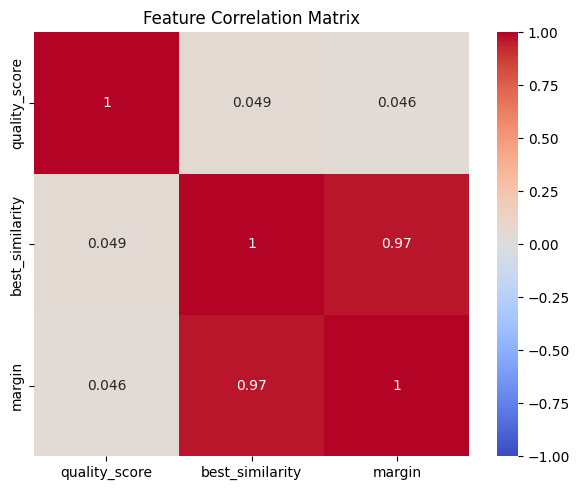

In [12]:
# feature correlation heatmap
features = df[["quality_score", "best_similarity", "margin"]]

corr = features.corr()

# visualizing the features
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig("figures/feature_correlation.png", dpi=600, bbox_inches="tight")

plt.show()

/var/folders/_3/yd3b3hn969x1q8zrlng3h58w0000gn/T/ipykernel_6472/2779019132.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([accept["margin"], reject["margin"]], labels=["Accept", "Reject"])


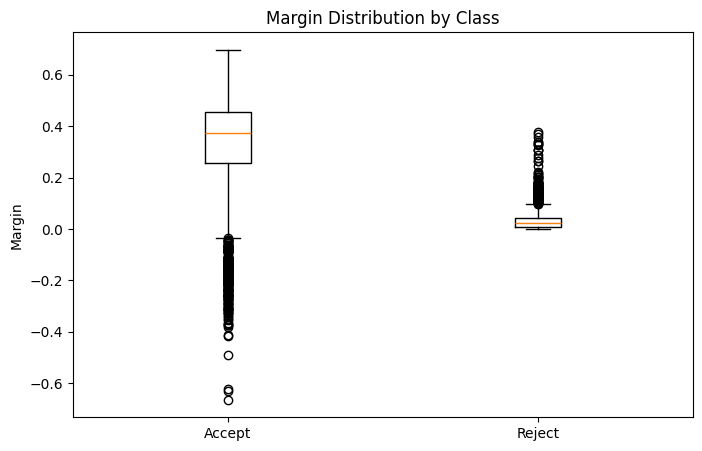

In [13]:
# feature boxplots
plt.figure(figsize=(8, 5))

plt.boxplot([accept["margin"], reject["margin"]], labels=["Accept", "Reject"])

plt.ylabel("Margin")
plt.title("Margin Distribution by Class")

plt.savefig("figures/margin_class_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

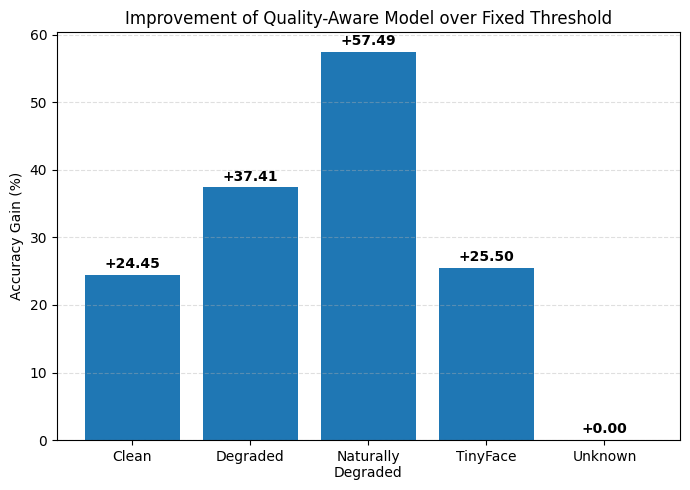

In [14]:
# accuracy gain over threshold
import matplotlib.pyplot as plt

datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
    "Unknown",
]

gain = [
    97.78 - 73.33,
    97.78 - 60.37,
    69.39 - 11.90,
    77.50 - 52.00,
    100.00 - 100.00,
]

plt.figure(figsize=(7, 5))

bars = plt.bar(datasets, gain)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"+{bar.get_height():.2f}",
        ha="center",
        fontweight="bold",
    )

plt.ylabel("Accuracy Gain (%)")
plt.title("Improvement of Quality-Aware Model over Fixed Threshold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("figures/accuracy_gain.png", dpi=600, bbox_inches="tight")

plt.show()

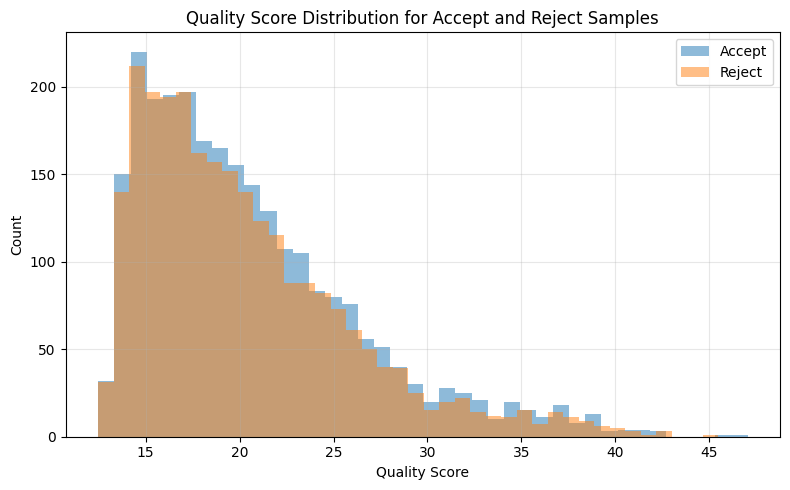

In [15]:
# quality score distribution
plt.figure(figsize=(8, 5))

plt.hist(accept["quality_score"], bins=40, alpha=0.5, label="Accept")

plt.hist(reject["quality_score"], bins=40, alpha=0.5, label="Reject")

plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.title("Quality Score Distribution for Accept and Reject Samples")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("figures/quality_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

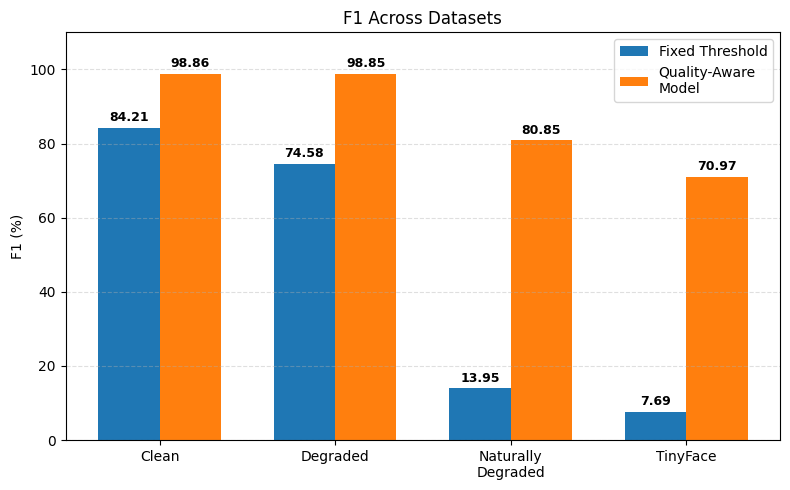

In [16]:
# F1 comparison

datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
]

threshold_f1 = [
    84.21,
    74.58,
    13.95,
    7.69,
]

mlp_f1 = [
    98.86,
    98.85,
    80.85,
    70.97,
]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    threshold_f1,
    width,
    label="Fixed Threshold",
)

bars2 = plt.bar(
    x + width / 2,
    mlp_f1,
    width,
    label="Quality-Aware\nModel",
)

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, datasets)
plt.ylabel("F1 (%)")
plt.title("F1 Across Datasets")
plt.legend()

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "figures/f1_comparison.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

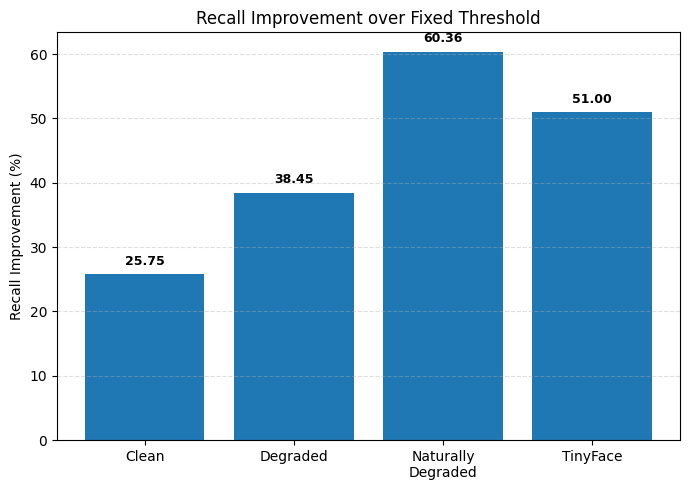

In [17]:
# recall improvement
datasets = [
    "Clean",
    "Degraded",
    "Naturally\nDegraded",
    "TinyFace",
]

improvement = [
    98.48 - 72.73,
    97.92 - 59.47,
    67.86 - 7.50,
    55.00 - 4.00,
]

plt.figure(figsize=(7, 5))

bars = plt.bar(datasets, improvement)

add_labels(bars)

plt.ylabel("Recall Improvement (%)")

plt.title("Recall Improvement over Fixed Threshold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "figures/recall_improvement.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()